In [1]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Configuration

# log_dirs = ["../raw_data/local_5_5", "../raw_data/local_20_20"]
log_basedir = "../raw_data"
test_runner_log_filename = "test-runner.log"
enforcer_log_filename = "enforcer.log"
asmeta_server_log_filename = "asmeta-server.log"

test_runner_output_filename = "extracted_test_runner_data.csv"
enforcer_output_filename = "extracted_enforcer_data.csv"
asmeta_output_filename = "extracted_asmeta_data.csv"

full_dataset_output_filename = "full_data.csv"

ping_file = "../raw_data/ping.txt"

log_pattern = re.compile(
    r"Test #(\d+): time: (.*?) ms"
)
enforcer_delay_pattern = re.compile(r"delay\s+([0-9]+(?:\.[0-9]+)?)\s+ms")
asmeta_server_execution_pattern = re.compile(r"Execution time \(in milliseconds\):\s+([0-9]+(?:\.[0-9]+)?)\s+ms")
ping_log_pattern = re.compile(r"time=([\d.]+)\s*ms")

In [3]:
# Build list of subdirectories under log_basedir
if os.path.exists(log_basedir) and os.path.isdir(log_basedir):
    log_dirs = [
        os.path.join(log_basedir, name)
        for name in sorted(os.listdir(log_basedir))
        if os.path.isdir(os.path.join(log_basedir, name))
    ]
else:
    print(f"Directory not found: {log_basedir}")
    log_dirs = []

print(f"Found {len(log_dirs)} log directories.")

Found 110 log directories.


## Enforcement Subsystem data analysis
Computed through data obtained by the Test Runner

In [4]:
# Data extraction and file saving

records = []

for log_dir in log_dirs:
    experiment_id = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, test_runner_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = log_pattern.search(line)
            if match:
                test_case_number = int(match.group(1))

                time_ms = match.group(2)

                records.append({
                    "experiment": experiment_id,
                    "test_case_number": test_case_number,
                    "delay_ms": time_ms
                })

df_test_runner_raw = pd.DataFrame(records)
df_test_runner_raw["delay_ms"] = pd.to_numeric(df_test_runner_raw["delay_ms"], errors="coerce")

df_test_runner_raw

,experiment,test_case_number,delay_ms
0,test_10_10,1,268
1,test_10_10,2,118
2,test_10_10,3,121
3,test_10_10,4,122
4,test_10_10,5,114
...,...,...,...
5495,test_60_8,46,677
5496,test_60_8,47,675
5497,test_60_8,48,673
5498,test_60_8,49,676


In [5]:
# Dataset cleaning

mask = df_test_runner_raw["delay_ms"] < 4
replaced_count = int(mask.sum())
df_test_runner_raw.loc[mask, "delay_ms"] = float("nan")

print(f"Replaced {replaced_count} entries with NaN.")

Replaced 0 entries with NaN.


In [6]:
if not df_test_runner_raw.empty:
    test_runner_stats = df_test_runner_raw.groupby("experiment")["delay_ms"].describe()

    test_runner_stats["90%"] = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.90)
    test_runner_stats["95%"] = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.95)
    test_runner_stats["99%"] = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.99)

    test_runner_stats["variance"] = df_test_runner_raw.groupby("experiment")["delay_ms"].var()

    ordered = ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "95%", "99%", "max", "variance"]
    cols = [c for c in ordered if c in test_runner_stats.columns]
    test_runner_stats = test_runner_stats[cols]

    print("Stats for the enforcement subsystem delay:")
    display(test_runner_stats)

    test_runner_stats.to_csv(test_runner_output_filename)

Stats for the enforcement subsystem delay:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,variance
experiment,,,,,,,,,,,,
test_10_10,50.0,88.24,54.128931,64.0,70.00,73.0,79.00,114.4,121.55,334.30,398.0,2929.941224
test_10_12,50.0,100.74,54.205132,76.0,83.00,85.5,91.50,133.4,148.00,347.94,394.0,2938.196327
test_10_14,50.0,119.04,46.374676,95.0,101.25,107.5,113.00,150.6,172.40,305.00,403.0,2150.610612
test_10_16,50.0,134.88,70.596479,110.0,116.00,119.0,123.75,132.3,163.75,472.93,494.0,4983.862857
test_10_18,50.0,156.48,57.275289,133.0,141.00,144.0,151.75,165.3,189.85,391.88,533.0,3280.458776
...,...,...,...,...,...,...,...,...,...,...,...,...
test_60_2,50.0,86.66,27.962519,71.0,75.00,78.0,83.00,114.5,124.20,191.22,251.0,781.902449
test_60_20,50.0,6862.08,148.294363,6778.0,6822.00,6836.5,6850.75,6894.1,6922.40,7454.47,7845.0,21991.217959
test_60_4,50.0,168.84,38.004490,149.0,155.00,159.0,164.50,174.5,218.05,331.65,388.0,1444.341224


## Enforcer data analysis

In [7]:
enforcer_iteration_records = []

for log_dir in log_dirs:
    experiment = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, enforcer_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        counter = 0
        for line in f:
            match = enforcer_delay_pattern.search(line)
            if match:
                delay_value = float(match.group(1))
                counter += 1
                enforcer_iteration_records.append({
                    "experiment": experiment,
                    "test_case_number": counter,
                    "delay_ms": delay_value,
                })

df_enforcer_raw = pd.DataFrame(enforcer_iteration_records)
df_enforcer_raw


,experiment,test_case_number,delay_ms
0,test_10_10,1,217.65
1,test_10_10,2,95.98
2,test_10_10,3,95.56
3,test_10_10,4,98.18
4,test_10_10,5,90.61
...,...,...,...
5495,test_60_8,46,653.06
5496,test_60_8,47,650.21
5497,test_60_8,48,651.14
5498,test_60_8,49,652.26


In [8]:
if not df_enforcer_raw.empty:
    enforcer_stats = df_enforcer_raw.groupby("experiment")["delay_ms"].describe()

    enforcer_stats["90%"] = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.90)
    enforcer_stats["95%"] = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.95)
    enforcer_stats["99%"] = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.99)

    enforcer_stats["variance"] = df_enforcer_raw.groupby("experiment")["delay_ms"].var()

    ordered = ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "95%", "99%", "max", "variance"]
    cols = [c for c in ordered if c in enforcer_stats.columns]
    enforcer_stats = enforcer_stats[cols]

    print("Stats for the enforcer delay:")
    display(enforcer_stats)

    enforcer_stats.to_csv(enforcer_output_filename)

Stats for the enforcer delay:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,variance
experiment,,,,,,,,,,,,
test_10_10,50.0,59.7946,26.523392,45.05,48.8950,51.160,55.9575,80.674,95.7910,159.1097,217.65,703.490307
test_10_12,50.0,72.7032,29.117241,57.16,61.8925,63.430,68.9775,94.841,116.5760,185.0652,242.65,847.813732
test_10_14,50.0,92.4966,34.612625,73.77,78.0375,83.805,89.7975,107.722,140.1715,226.7457,302.73,1198.033790
test_10_16,50.0,106.8968,45.259273,89.78,94.1000,96.610,100.3250,110.586,142.6625,298.1747,396.65,2048.401769
test_10_18,50.0,133.1790,53.356406,113.40,117.0425,121.330,128.4375,141.770,162.9510,354.2931,483.07,2846.906017
...,...,...,...,...,...,...,...,...,...,...,...,...
test_60_2,50.0,62.8708,24.497431,48.19,51.8775,55.015,59.4625,90.108,98.4350,153.5298,201.05,600.124130
test_60_20,50.0,6833.0856,142.814104,6748.24,6794.1325,6808.695,6822.9625,6863.468,6896.4250,7405.3955,7775.86,20395.868376
test_60_4,50.0,145.7710,34.805295,128.99,133.1975,135.295,139.3200,155.521,196.7805,294.9220,337.16,1211.408528


## ASMETA Server data analysis

In [9]:
asmeta_enforcement_records = []

for log_dir in log_dirs:
    experiment = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, asmeta_server_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        counter = 0
        for line in f:
            match = asmeta_server_execution_pattern.search(line)
            if match:
                delay_value = float(match.group(1))
                counter += 1
                asmeta_enforcement_records.append({
                    "experiment": experiment,
                    "test_case_number": counter,
                    "delay_ms": delay_value
                })

df_asmeta_raw = pd.DataFrame(asmeta_enforcement_records)
df_asmeta_raw

,experiment,test_case_number,delay_ms
0,test_10_10,1,109.0
1,test_10_10,2,33.0
2,test_10_10,3,38.0
3,test_10_10,4,39.0
4,test_10_10,5,38.0
...,...,...,...
5495,test_60_8,46,603.0
5496,test_60_8,47,597.0
5497,test_60_8,48,601.0
5498,test_60_8,49,598.0


In [10]:
if not df_asmeta_raw.empty:
    asmeta_stats = df_asmeta_raw.groupby("experiment")["delay_ms"].describe()

    asmeta_stats["90%"] = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.90)
    asmeta_stats["95%"] = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.95)
    asmeta_stats["99%"] = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.99)

    asmeta_stats["variance"] = df_asmeta_raw.groupby("experiment")["delay_ms"].var()

    ordered = ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "95%", "99%", "max", "variance"]
    cols = [c for c in ordered if c in asmeta_stats.columns]
    asmeta_stats = asmeta_stats[cols]

    print("Stats for the asmeta delay:")
    display(asmeta_stats)

    asmeta_stats.to_csv(asmeta_output_filename)

Stats for the asmeta delay:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,variance
experiment,,,,,,,,,,,,
test_10_10,50.0,22.44,14.083077,16.0,17.00,18.0,21.00,33.0,38.00,74.70,109.0,198.333061
test_10_12,50.0,29.80,18.001134,23.0,23.00,24.0,26.00,43.4,54.00,102.21,137.0,324.040816
test_10_14,50.0,41.06,23.316290,31.0,32.25,35.0,39.00,52.0,65.95,131.67,189.0,543.649388
test_10_16,50.0,49.30,32.785792,40.0,41.00,42.0,44.00,47.1,67.60,188.03,263.0,1074.908163
test_10_18,50.0,62.42,40.669946,50.0,52.00,54.0,56.00,65.9,84.30,227.65,333.0,1654.044490
...,...,...,...,...,...,...,...,...,...,...,...,...
test_60_2,50.0,30.62,14.288414,23.0,24.00,25.0,28.75,47.3,51.55,83.03,109.0,204.158776
test_60_20,50.0,6680.32,124.732111,6604.0,6644.50,6659.5,6673.75,6706.4,6734.25,7173.78,7506.0,15558.099592
test_60_4,50.0,108.96,25.311899,98.0,100.00,101.0,104.00,113.8,149.50,218.50,243.0,640.692245


## Creating full dataset

In [11]:
df_tr = df_test_runner_raw.copy()
df_tr["component"] = "test_runner"

df_enf = df_enforcer_raw.copy()
df_enf["component"] = "enforcer"

df_asm = df_asmeta_raw.copy()
df_asm["component"] = "asmeta"

df_full = pd.concat([df_tr, df_enf, df_asm], ignore_index=True, sort=False)
df_full = df_full[["experiment", "component", "test_case_number", "delay_ms"]]

df_full["rules"] = df_full["experiment"].apply(lambda x: int(re.search(r'_(\d+)_(\d+)$', x).group(1)))
df_full["clauses_per_rule"] = df_full["experiment"].apply(lambda x: int(re.search(r'_(\d+)_(\d+)$', x).group(2)))
df_full["conditions_checked"] = df_full["rules"] * df_full["clauses_per_rule"]

ordered = ["experiment", "component", "rules", "clauses_per_rule", "conditions_checked", "test_case_number", "delay_ms"]
cols = [c for c in ordered if c in df_full.columns]
df_full = df_full[cols]

df_full["component"] = pd.Categorical(df_full["component"],
                                     categories=["test_runner", "enforcer", "asmeta"],
                                     ordered=True)
df_full = df_full.sort_values(["component", "conditions_checked", "test_case_number"]).reset_index(drop=True)

display(df_full)

df_full.to_csv(full_dataset_output_filename)

,experiment,component,rules,clauses_per_rule,conditions_checked,test_case_number,delay_ms
0,test_10_2,test_runner,10,2,20,1,150.0
1,test_10_2,test_runner,10,2,20,2,62.0
2,test_10_2,test_runner,10,2,20,3,66.0
3,test_10_2,test_runner,10,2,20,4,65.0
4,test_10_2,test_runner,10,2,20,5,57.0
...,...,...,...,...,...,...,...
16495,test_60_20,asmeta,60,20,1200,46,6654.0
16496,test_60_20,asmeta,60,20,1200,47,6613.0
16497,test_60_20,asmeta,60,20,1200,48,6643.0
16498,test_60_20,asmeta,60,20,1200,49,6652.0


## Data reporting

In [12]:
df_overall_mean = pd.concat(
    [df_test_runner_raw.groupby("experiment")["delay_ms"].mean().rename("enforcement_subsystem"),
     df_enforcer_raw.groupby("experiment")["delay_ms"].mean().rename("enforcer"),
     df_asmeta_raw.groupby("experiment")["delay_ms"].mean().rename("asmeta_server")],
    axis=1
).reset_index()

df_overall_mean["rules"] = df_overall_mean["experiment"].apply(lambda x: int(re.search(r'_(\d+)_(\d+)$', x).group(1)))
df_overall_mean["clauses_per_rule"] = df_overall_mean["experiment"].apply(lambda x: int(re.search(r'_(\d+)_(\d+)$', x).group(2)))
df_overall_mean["conditions_checked"] = df_overall_mean["rules"] * df_overall_mean["clauses_per_rule"]

df_overall_mean = df_overall_mean[["experiment", "rules", "clauses_per_rule", "conditions_checked", "enforcement_subsystem", "enforcer", "asmeta_server"]].sort_values(by=["conditions_checked"])

df_overall_mean

,experiment,rules,clauses_per_rule,conditions_checked,enforcement_subsystem,enforcer,asmeta_server
5,test_10_2,10,2,20,52.06,29.0418,3.06
15,test_15_2,15,2,30,56.84,33.1718,5.10
25,test_20_2,20,2,40,53.14,31.2408,6.36
7,test_10_4,10,4,40,65.30,36.2528,6.96
35,test_25_2,25,2,50,54.56,32.8150,7.96
...,...,...,...,...,...,...,...
94,test_55_18,55,18,990,4136.06,4108.6490,3986.06
86,test_50_20,50,20,1000,4271.96,4244.8834,4107.32
104,test_60_18,60,18,1080,5100.96,5072.9712,4941.82
96,test_55_20,55,20,1100,5330.00,5302.2160,5156.44


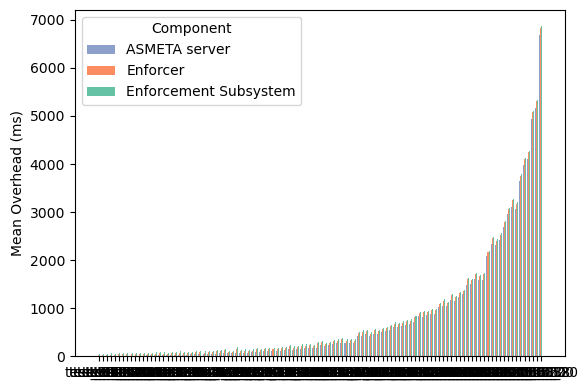

In [13]:
df_bar_plot = df_overall_mean.set_index("experiment")[["asmeta_server", "enforcer", "enforcement_subsystem"]]
labels = ["ASMETA server", "Enforcer", "Enforcement Subsystem"]

x = np.arange(len(df_bar_plot.index))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 4))
palette = sns.color_palette("Set2", 3)
palette.reverse()

for i, col in enumerate(df_bar_plot.columns):
    ax.bar(x + (i - 1) * width, df_bar_plot[col].values, width, label=labels[i], color=palette[i])

ax.set_xticks(x)
ax.set_xticklabels(df_bar_plot.index, rotation=0)
ax.set_ylabel("Mean Overhead (ms)")
ax.set_xlabel("")
ax.legend(title="Component")

plt.tight_layout()
plt.show()


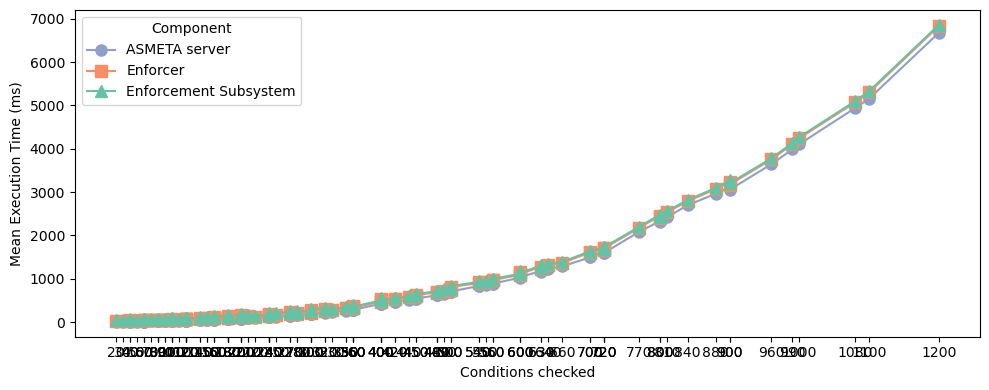

In [14]:
df_xy_plot = df_overall_mean.set_index("conditions_checked")[["asmeta_server", "enforcer", "enforcement_subsystem"]]

markers = ['o', 's', '^']
labels = ["ASMETA server", "Enforcer", "Enforcement Subsystem"]
palette = sns.color_palette("Set2", 3)
palette.reverse()

fig, ax = plt.subplots(figsize=(10, 4))

x = df_xy_plot.index.values
for col, marker, label, color in zip(df_xy_plot.columns, markers, labels, palette):
    y = df_xy_plot[col].values
    ax.plot(x, y, marker=marker, linestyle='-', markersize=8, color=color, label=label)

ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_xlabel("Conditions checked")
ax.set_ylabel("Mean Execution Time (ms)")
ax.legend(title="Component")
plt.tight_layout()
plt.show()